In [16]:
import numpy as np
import config
from model_classes import LCDataset, LCModel
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
from sklearn.preprocessing import MinMaxScaler


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
dataset = LCDataset('data.npy')
mag_max, mag_min, y_max, y_min = dataset.mag_max, dataset.mag_min, dataset.y_max, dataset.y_min
model = LCModel(None, None, None, None).to(device)
model.load_state_dict(torch.load('current_model.pth'))
dataset = LCDataset('data.npy')
model.eval()


Using device: cuda


LCModel(
  (conv): Sequential(
    (0): Conv1d(2, 64, kernel_size=(5,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): AdaptiveAvgPool1d(output_size=32)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=5, bias=True)
  )
)

In [18]:
f = np.logspace(np.log10(10), np.log10(10E9), config.freq_length)

fc = 1E3
BW = 1E6
hf = 1/(1 + 1j*f/fc) # artificating at fc = 10 kHz
#hf = (1j*f/fc)/((1 + 1j*f/fc)*(1 + 1j*f/(fc + BW)))
#hf = (1j*f/fc)/(1 + 1j*f/fc)

mag = 20*np.log10(np.abs(hf))
mag_norm = 2*(mag - mag_min)/(mag_max - mag_min) - 1
phase = np.angle(hf)
phase = np.unwrap(phase)/np.pi

[2.43413038e+03 3.79955327e-01 4.20090511e+00 1.07070424e-01
 2.12554208e-02]


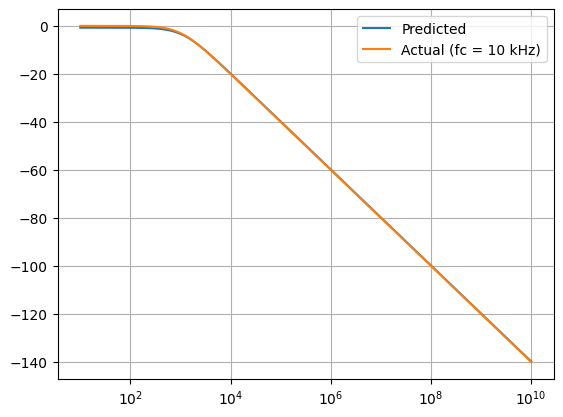

In [19]:
X = np.stack([mag_norm, phase], axis=0)[np.newaxis, :, :]
X = torch.tensor(X, dtype=torch.float32).to(device)
with torch.inference_mode():
    pred = model(X)

pred = pred.detach().cpu().numpy()
#pred = y_scaler.inverse_transform(pred)

comps = (pred[0]+1)*(y_max - y_min)/2 + y_min
comps = 10**comps

R, L1, L2, C1, C2 = comps
print(comps)

s = 1j*2*np.pi*f
yf = (C1*s)/((C1*L1*s**2 + 1)*(1/R + (C1*s)/(C1*L1*s**2 + 1) + (C2*s)/(C2*L2*s**2 + 1)))
yf_dB = 20*np.log10(np.abs(yf))

plt.semilogx(f, yf_dB, f, mag)
plt.legend(['Predicted', 'Actual (fc = 10 kHz)'])
plt.grid()
plt.show()

In [20]:
MSE = np.mean((mag - yf_dB)**2)
print(MSE)

0.12869499020647815
